# Workstream 2: Predictive Modelling

**Target:** Total GHG excl LULUCF (Mt CO₂e)
<br> **Data:** 135 countries × 25 years (2000–2024), from WS1
<br> **Primary model:** Fixed-effects data regression (manual demeaning + OLS)
<br> **Comparison model:** XGBoost (gradient boosting)
<br> **Prediction year:** 2024
<br> **Output:** Coefficient table, validation metrics, 2024 predictions (for WS4 & dashboard)

| Step | What | Output |
|------|------|--------|
| **1 Data Preparation** | (A) Load WS1 data CSV; <br>(B) Log-transform level variables; <br>(C) Split into Train / Valid / Pred sets | `Train`, `Valid`, `Pred` |
| **2 Fixed-Effects Regression** | (A) Country means from training; <br>(B) Demean and fit OLS; <br>(C) Sanity check training R² | `Coef_Df`, `OLS` model |
| **3 Model Diagnostics** | (A) Validation metrics; <br>(B) Residual plots; <br>(C) Breusch–Pagan heteroscedasticity; <br>(D) Hausman test (FE vs RE) | Diagnostic charts + test results |
| **4 XGBoost & Model Comparison** | (A) Fit XGBoost; <br>(B) Side-by-side metrics; <br>(C) Feature importance; <br>(D) Actual vs predicted scatter | Comparison table |
| **5 2024 Prediction** | (A) Predict 2024 (both models); <br>(B) SE Asia focus table + bar chart; <br>(C) 95% confidence interval | `Results` table |
| **6 Export** | Save coefficients, metrics, predictions, country means for WS4 & dashboard | Export CSVs to Data_Path |

## Working Directory
Set `Drive_Path` to your local project folder (only thing to change).
<br> All other paths derive from it.

In [45]:
from pathlib import Path
import os

## Only change this line: 
Drive_Path = Path.home() / "Desktop/MASAHKT2026/Model"

In [46]:
# Define subdirectories
Data_Path = Drive_Path / "Data"
Code_Path = Drive_Path / "Code"
Output_Path = Drive_Path / "Output"
Output_WS1 = Output_Path / "Output_WS1"
Output_WS2 = Output_Path / "Output_WS2"
Output_WS3 = Output_Path / "Output_WS3"
Output_WS4 = Output_Path / "Output_WS4"

# Define input file name
WDI_Filename = 'WB_WDI_WIDEF.csv'
Data_Filename = 'WS1_Data_Imputed.csv'
# Source note for data (Chart footnote)
WDI_Source = 'Source: World Bank WDI (Wide Format), accessed 2026-04-26' 

# Create folders if they don't exist
for p in [Data_Path, Code_Path, Output_Path,Output_WS1, Output_WS2, Output_WS3, Output_WS4]:
    p.mkdir(parents=True, exist_ok=True)

## Setup
* Import libraries
* Define constants: 
<br> (i) Target, (ii) Predictors, (iii) Log-transform list, (iv) SE Asia countries

In [47]:
try:
    import linearmodels
except ImportError:
    !pip install linearmodels -q

# Other libraries come with Anaconda, only this one needs to be installed separately

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan
from linearmodels import PanelOLS, RandomEffects
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
sns.set_theme(style='whitegrid', font_scale=0.9)

# Column names matching WS1 output CSV
Target    = 'Total_GHG'
Pred_Cols = ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita',
             'Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%']

# Level variables → log; 
# Percentages → stay in levels
Log_Vars = [Target, 'Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita']


SE_Asia = ['BRN', 'KHM', 'IDN', 'LAO', 'MYS', 'MMR', 'PHL', 'SGP', 'THA', 'TLS', 'VNM']

print('Setup complete.')

Setup complete.


## Helper Functions

- **`Calc_Metrics`**
<br> Computes RMSE, MAE, R², MAPE for log-scale predictions. 
<br> MAPE is on original scale (exponentiated) for interpretability.

- **`FE_Predict`** 
<br> Predicts ln(GHG) using the FE model formula: 
   > ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train)). 

     Falls back to global mean for countries not in training.

In [49]:
def Calc_Metrics(actual, predicted, label=''):
    """Compute RMSE, MAE, R², MAPE for log-scale predictions."""
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    r2   = r2_score(a, p)
    mape = np.mean(np.abs((np.exp(a) - np.exp(p)) / np.exp(a))) * 100
    if label:
        print(f'{label}')
        print(f'  RMSE (log scale):  {rmse:.4f}')
        print(f'  MAE  (log scale):  {mae:.4f}')
        print(f'  R²:                {r2:.4f}')
        print(f'  MAPE (orig scale): {mape:.1f}%')
    return {'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'R2': round(r2, 4), 'MAPE': round(mape, 1)}


def FE_Predict(data, coefs, country_means_y, country_means_X, x_cols):
    """Predict ln(GHG) using FE model. Falls back to global mean for unseen countries."""
    predictions = np.full(len(data), np.nan)
    global_mean_y = country_means_y.mean()
    global_mean_X = country_means_X.mean()

    for idx, (_, row) in enumerate(data.iterrows()):
        country = row['Ref_Area']
        x_vals  = row[x_cols].values.astype(float)

        if country in country_means_y.index:
            y_bar = country_means_y[country]
            x_bar = country_means_X.loc[country].values
        else:
            y_bar = global_mean_y
            x_bar = global_mean_X.values

        predictions[idx] = y_bar + coefs @ (x_vals - x_bar)

    return predictions


print('Helpers ready.')

Helpers ready.


## Step 1: Data Preparation

### Step 1(A) Load Data
Read the imputed data from WS1. 

In [50]:
# (A) Load WS1 output: WS1_Data_Imputed.csv
Data = pd.read_csv(Data_Path / Data_Filename)

# Verify handoff
for col in [Target] + Pred_Cols:
    assert col in Data.columns, f'Missing column: {col}'

print(f'Data:   {Data.Ref_Area.nunique()} countries × {Data.Year.nunique()} years')
print(f'Rows:    {len(Data)}')
print(f'Years:   {Data.Year.min()}–{Data.Year.max()}')
print(f'SE Asia: {all(c in Data.Ref_Area.values for c in SE_Asia)}')
print(f'Columns: {list(Data.columns)}')

Data:   130 countries × 25 years
Rows:    3250
Years:   2000–2024
SE Asia: False
Columns: ['Ref_Area', 'Year', 'Total_GHG', 'Energy_Per_Capita', 'Elec_Per_Capita', 'Renewable_%', 'Fossil_Elec_%', 'Renew_Elec_%', 'GDP_Total', 'GDP_Per_Capita', 'GDP_Per_Capita_PPP', 'Population', 'Urban_%', 'Industry_VA_%', 'Agri_VA_%', 'Forest_%', 'Agri_Land_%', 'Covid']


### Step 1(B) Log-transform
1. **Level variables** are log-transformed per STIRPAT specification. 
    * This makes the relationship approximately linear and coefficients interpretable as elasticities. 

      > Predictor: Population, GDP_Per_Capita_PPP, Energy_Per_Capita
      >> Target   : Total_GHG

2. **Percentage variables** stay in levels. 

    * Their coefficients are semi-elasticities.
      > Predictor: Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%'

In [51]:
# Log-transform level variables, Keep percentages in levels

# Model data
# - Add ln_ columns to logged variables
for col in Log_Vars:
    Data[f'ln_{col}'] = np.log(Data[col].replace(0, np.nan))

# Model column names 
# - ln_ prefix for logged variables
Target    = f'ln_{Target}'
Pred_Cols = [f'ln_{col}' if col in Log_Vars else col for col in Pred_Cols]

print(f'Target:     {Target}')
print(f'Predictors: {Pred_Cols}')

Target:     ln_Total_GHG
Predictors: ['ln_Population', 'ln_GDP_Per_Capita_PPP', 'ln_Energy_Per_Capita', 'Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%']


### Step 1(C) Split Data

| Set | Years | Purpose |
|---|---|---|
| Train | 2000–2018 | Model estimation |
| Validation | 2019, 2022, 2023 | Out-of-sample evaluation |
| Prediction | 2024 | Forecast: Compare predicted vs actual |

<br>

> 2020–2021 excluded entirely (pandemic distortion).

   * The emission drop reflects economic shutdown, not climate dynamics. 

<br>

> Indicator selection, VIF screening, and stationarity tests were completed in WS1. 

This step starts from the cleaned, validated predictor set.

In [52]:
Model_Vars  = [Target] + Pred_Cols
Data_Complete = Data.dropna(subset = Model_Vars)
Data_Model    = Data_Complete[~Data_Complete.Year.isin([2020, 2021])]

Train = Data_Model[Data_Model.Year <= 2018].copy()
Valid   = Data_Model[Data_Model.Year.isin([2019, 2022, 2023])].copy()
Pred  = Data_Model[Data_Model.Year == 2024].copy()

print(f'Complete (excl Covid): {len(Data_Model)} rows')
print(f'')
print(f'Train: {len(Train)} ({Train.Year.min()}–{Train.Year.max()}, {Train.Ref_Area.nunique()} countries)')
print(f'Val:   {len(Valid)}  (Years: {sorted(Valid.Year.unique())})')
print(f'Pred:  {len(Pred)}  (2024, {Pred.Ref_Area.nunique()} countries)')

Complete (excl Covid): 2962 rows

Train: 2442 (2000–2018, 130 countries)
Val:   390  (Years: [2019, 2022, 2023])
Pred:  130  (2024, 130 countries)


## Step 2: Fixed-Effects Data Regression

**Fixed effects** gives each country its own intercept (αᵢ), absorbing time-invariant characteristics like *geography and institutions*. 

The coefficients then capture **within-country** changes only.
* e.g. how Thailand's GHG moves when Thailand's renewable share increases.

**Implementation:** Equivalent to OLS on country-demeaned data.
* Step 2(A) For each variable, subtract the country's training-set mean
* Step 2(B) Run OLS without intercept (demeaning removes it)
* Step 2(C) Verify training R² is close to 1.0 as a sanity check

**Prediction formula:**
<br> ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train))

Country means are fixed from training, so the formula works for any year. 
<br> including out-of-sample validation and 2024 prediction.

**How to read the coefficients:**
1. **Log–log** 
<br> Variables (Population, GDP/cap, Energy/cap): **elasticities**. 
<br> e.g. coefficient 0.69 on ln(Population) means a 1% increase in population → 0.69% increase in GHG.
2. **Level–log** 
<br> Variables (Renewable%, Urban%, Forest%, Agri VA%): **semi-elasticities**. 
<br> e.g. coefficient −0.011 on Renewable% means a 1 percentage-point increase in renewables → 1.1% decrease in GHG.

### Step 2(A) Country Means from Training Set

In [53]:
Country_Means_y = Train.groupby('Ref_Area')[Target].mean()
Country_Means_X = Train.groupby('Ref_Area')[Pred_Cols].mean()

print(f'Country means computed from {len(Train)} training observations')
print(f'Countries: {len(Country_Means_y)}')

Country means computed from 2442 training observations
Countries: 130


### Step 2(B) Demean and Fit 

Demeaning removes each country's average from every variable, so OLS estimates only within-country variation. 
<br> No intercept is needed, demeaning already centres the data at zero.

Standard errors are adjusted for degrees of freedom lost to the absorbed country fixed effects (N − K − N_countries).

In [54]:
Train_Demeaned = Train.copy()
Train_Demeaned[Target] = Train[Target] - Train['Ref_Area'].map(Country_Means_y)
for col in Pred_Cols:
    Train_Demeaned[col] = Train[col] - Train['Ref_Area'].map(Country_Means_X[col])

# OLS on demeaned data, no intercept (demeaning removes it)
OLS = LinearRegression(fit_intercept=False)
OLS.fit(Train_Demeaned[Pred_Cols].values, Train_Demeaned[Target].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 2(C) Training Sanity Check

Overall R² (including country intercepts) should be close to 1.0. 
<br> If not, something went wrong in demeaning or fitting.

In [55]:
# Standard errors & coefficient table 
# SE = sqrt(diag(σ² · (X'X)⁻¹))
# DoF adjusted for absorbed country fixed effects
X_Mat = Train_Demeaned[Pred_Cols].values
y_Vec = Train_Demeaned[Target].values
Resid = y_Vec - X_Mat @ OLS.coef_

n, k        = X_Mat.shape
n_countries = Train.Ref_Area.nunique()
dof         = n - k - n_countries
sigma2      = np.sum(Resid**2) / dof
XtX_inv     = np.linalg.inv(X_Mat.T @ X_Mat)
se          = np.sqrt(np.diag(sigma2 * XtX_inv))

coef_df = pd.DataFrame({
    'Variable':    Pred_Cols,
    'Coefficient': OLS.coef_.round(4),
    'Std Error':   se.round(4),
})
coef_df['t-stat']  = (coef_df['Coefficient'] / coef_df['Std Error']).round(2)
coef_df['p-value'] = [2 * (1 - stats.t.cdf(abs(t), dof)) for t in coef_df['t-stat']]
coef_df['Sig']     = coef_df['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Within R²
ss_res    = np.sum(Resid**2)
ss_tot    = np.sum((y_Vec - y_Vec.mean())**2)
within_r2 = 1 - ss_res / ss_tot

print('=' * 72)
print('   Fixed-Effects Data Regression — Coefficients')
print('=' * 72)
print(coef_df.to_string(index=False))
print(f'\nWithin R²:    {within_r2:.4f}')
print(f'Observations: {n}')
print(f'Countries:    {n_countries}')
print(f'Residual SE:  {np.sqrt(sigma2):.4f}')

   Fixed-Effects Data Regression — Coefficients
             Variable  Coefficient  Std Error  t-stat      p-value Sig
        ln_Population       0.6934     0.0199   34.84 0.000000e+00 ***
ln_GDP_Per_Capita_PPP       0.2275     0.0124   18.35 0.000000e+00 ***
 ln_Energy_Per_Capita       0.4547     0.0147   30.93 0.000000e+00 ***
          Renewable_%      -0.0105     0.0004  -26.25 0.000000e+00 ***
              Urban_%      -0.0045     0.0007   -6.43 1.546159e-10 ***
             Forest_%      -0.0012     0.0017   -0.71 4.777760e-01    
            Agri_VA_%       0.0017     0.0008    2.12 3.411262e-02   *

Within R²:    0.7867
Observations: 2442
Countries:    130
Residual SE:  0.0773


In [56]:
# Quick sanity check: FE predictions on training data
Train_Pred = FE_Predict(Train, OLS.coef_, Country_Means_y, Country_Means_X, Pred_Cols)
Train_R2   = r2_score(Train[Target].values, Train_Pred)
print(f'Training R² (Overall, incl. country intercepts): {Train_R2:.4f}')

Training R² (Overall, incl. country intercepts): 0.9978


## Step 3: Model Diagnostics

Four checks to confirm the FE model is valid.

* Step 3(A) **Validation metrics**
<br>  - Out-of-sample test on 2019, 2022, 2023 (RMSE, MAE, R², MAPE).

* Step 3(B) **Residual plots** 
<br> - Histogram
<br> - Residuals vs fitted
<br> - Q-Q plot

* Step 3(C) **Breusch–Pagan**
<br> - Formal heteroscedasticity test. 

* Step 3(D) **Hausman test**
<br> - Confirms FE is the correct specification over random effects. 
<br> - *Uses clustered SE because 3(C) found heteroscedasticity.*


### Step 3(A) Validation Metrics

**Out-of-sample test** on years the model has never seen. 
<br> *Predict on test (2019, 2022, 2023) using country means from training (2000–2018).*

Country means are fixed from training (2000–2018), so the model can only succeed if the structural relationships generalise forward.

> **RMSE / MAE:** Prediction error in log scale (lower = better).
<br>**R²:** Proportion of variance explained (closer to 1 = better).
<br>**MAPE:** Average percentage error in original scale (most interpretable for the report).

In [57]:
Valid['FE_Pred']  = FE_Predict(Valid, OLS.coef_, Country_Means_y, Country_Means_X, Pred_Cols)
Valid['FE_Resid'] = Valid[Target] - Valid['FE_Pred']

print('=' * 72)
print('   FE Data Regression — Out-of-Sample Validation')
print('=' * 72)
FE_Val_Metrics = Calc_Metrics(Valid[Target].values, Valid['FE_Pred'].values,
                              'Validation (2019, 2022, 2023)')

   FE Data Regression — Out-of-Sample Validation
Validation (2019, 2022, 2023)
  RMSE (log scale):  0.1268
  MAE  (log scale):  0.0984
  R²:                0.9936
  MAPE (orig scale): 10.2%


### Step 3(B) Residual Plots

Three visual checks on the validation residuals:
1. **Histogram**
    <br> Should be symmetric around zero. 
    <br> Skew means systematic over/under-prediction.

2. **Residuals vs Fitted** 
    <br> Should show random scatter. 
    <br> A fan shape means variance grows with predicted values (heteroscedasticity).

3. **Q-Q Plot** 
    <br> Points on the diagonal mean residuals are normally distributed. 
    <br> Tail deviations mean some countries are harder to predict.

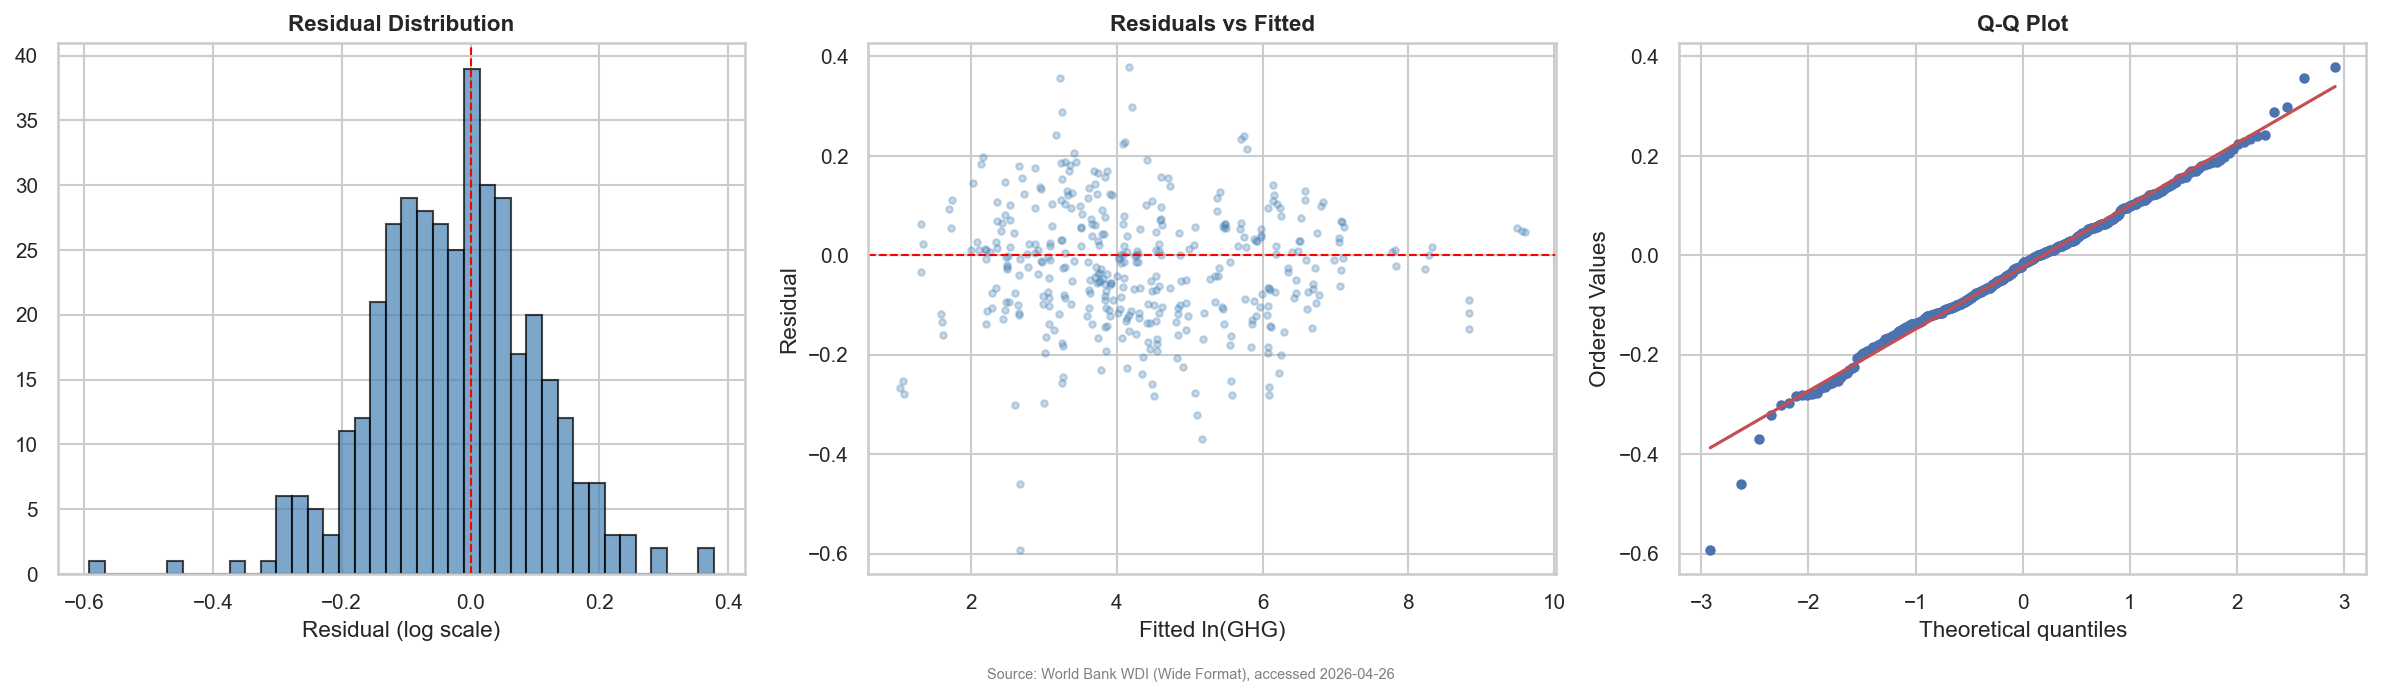

Saved: WS2_Residual_Diagnostics.png


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Histogram
axes[0].hist(Valid['FE_Resid'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (log scale)')

# Residuals vs fitted
axes[1].scatter(Valid['FE_Pred'], Valid['FE_Resid'], alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residuals vs Fitted', fontweight='bold')
axes[1].set_xlabel('Fitted ln(GHG)')
axes[1].set_ylabel('Residual')

# Q-Q plot
stats.probplot(Valid['FE_Resid'].dropna(), dist='norm', plot=axes[2])
axes[2].get_lines()[0].set_markersize(4)
axes[2].set_title('Q-Q Plot', fontweight='bold')

plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_Residual_Diagnostics.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_Residual_Diagnostics.png')

### Step 3(C) Breusch–Pagan Heteroscedasticity Test

Tests whether residual variance is constant across fitted values.
> **H₀:** Residual variance is constant (homoscedastic).
<br> **H₁:** Residual variance depends on predictors (heteroscedastic).

    If p < 0.05, standard errors from Step 2 may be slightly understated. 
   
If detected, Step 3(D) Hausman test will use clustered standard errors as mitigation.
<br> If not detected, standard errors from Step 2 are reliable.

In [59]:
# Add constant column (BP test requires it)
X_Mat_const = add_constant(X_Mat)

# Run on training residuals (where we have the full demeaned X matrix)
BP_Stat, BP_p, BP_F, BP_Fp = het_breuschpagan(Resid, X_Mat_const)

print('=' * 60)
print('   Breusch–Pagan Test (training residuals)')
print('=' * 60)
print(f'  LM statistic:  {BP_Stat:.2f}')
print(f'  LM p-value:    {BP_p:.6f}')
print(f'  F-statistic:   {BP_F:.2f}')
print(f'  F p-value:     {BP_Fp:.6f}')
if BP_p < 0.05:
    print(f'\n  Result: Heteroscedasticity detected (p < 0.05).')
    print(f'  → Standard errors from Step 2 may be slightly understated.')
    print(f'  → Step 3(D) Hausman test will use clustered SE as mitigation.')
else:
    print(f'\n  Result: No heteroscedasticity detected (p = {BP_p:.3f}).')
    print(f'  → Standard errors from Step 2 are reliable.')

   Breusch–Pagan Test (training residuals)
  LM statistic:  60.91
  LM p-value:    0.000000
  F-statistic:   8.89
  F p-value:     0.000000

  Result: Heteroscedasticity detected (p < 0.05).
  → Standard errors from Step 2 may be slightly understated.
  → Step 3(D) Hausman test will use clustered SE as mitigation.


### Step 3(D) Hausman Test (FE vs RE)

Clustered standard errors are used because Breusch–Pagan in Step 3(C) detected heteroscedasticity.

This test compares two data regression specifications:
* **Fixed Effects (FE):** 
  * Each country gets its own intercept. 
  * Always consistent, but less efficient.

* **Random Effects (RE):** 
  * Assumes country effects are random draws, uncorrelated with predictors.
  * More efficient if the assumption holds, but biased if it does not.

> **H₀:** Country effects are uncorrelated with predictors (RE is valid).
<br>**H₁:** Country effects are correlated with predictors (only FE is consistent).

     If p < 0.05, reject H₀ and use FE. 

*We expect rejection because country characteristics (geography, resource endowments) are inherently linked to predictors like GDP, energy use, and urbanisation.*

In [60]:
Train_Data = Train.set_index(['Ref_Area', 'Year'])

# FE with clustered standard errors (robust to heteroscedasticity)
FE_lm = PanelOLS(
    dependent=Train_Data[Target], exog=Train_Data[Pred_Cols],
    entity_effects=True, check_rank=False
).fit(cov_type='clustered', cluster_entity=True)

RE_lm = RandomEffects(
    dependent=Train_Data[Target], exog=Train_Data[Pred_Cols]
).fit()

# Hausman statistic: H = (b_FE - b_RE)' (V_FE - V_RE)^{-1} (b_FE - b_RE)
b_diff = FE_lm.params - RE_lm.params
v_diff = FE_lm.cov - RE_lm.cov
H = float(b_diff.values @ np.linalg.inv(v_diff.values) @ b_diff.values)
p = 1 - stats.chi2.cdf(H, df=len(b_diff))

print('=' * 60)
print('  Hausman Test: Fixed Effects vs Random Effects')
print('=' * 60)
print(f'  Chi² statistic: {H:.2f}')
print(f'  p-value:        {p:.6f}')
print(f'  DoF:            {len(b_diff)}')
print(f'\n  {"Reject H0 → FE preferred" if p < 0.05 else "Cannot reject H0"}')

  Hausman Test: Fixed Effects vs Random Effects
  Chi² statistic: 94.85
  p-value:        0.000000
  DoF:            7

  Reject H0 → FE preferred


## Step 4: XGBoost & Model Comparison

XGBoost (gradient-boosted trees) is fitted as a comparison model
* To test whether non-linear patterns exist that the linear FE model misses.

**Country identity** is encoded as each country's training-set mean of ln(GHG) (target mean-encoding). This give XGBoost a comparable "country baseline" to the fixed effects.

* Step 4(A) **Fit XGBoost**
<br>  - Train and validate on the same splits as FE.

* Step 4(B) **Side-by-side metrics** 
<br>  - Compare RMSE, MAE, R², MAPE.

* Step 4(C) **Feature importance** 
<br>  - Which inputs does XGBoost rely on most.

* Step 4(D) **Actual vs predicted** 
<br>  - Visual comparison of both models. 

<br> 
Even if XGBoost wins on metrics, FE remains the primary model because:

1. **WS4 needs coefficients**
<br>  - Stress testing requires Δln(GHG) = β × ΔX. 
<br>  - Tree models cannot isolate single-variable effects.
2. **Interpretability** 
<br>  - Coefficients are elasticities, directly communicable to a reinsurance board.
3. **Hausman confirms FE.** 
<br>  - XGBoost feature importance typically shows country encoding dominates. 
<br>  - *Memorising averages, not learning structural relationships.*


### Step 4(A) Fit XGBoost

Target mean-encoding: 
* Each country gets its training-set mean of ln(GHG) as an additional feature. 
* Countries not in training fall back to the global mean.

In [61]:
# Country mean-encoding
Country_Enc_Map = Train.groupby('Ref_Area')[Target].mean()
Global_Enc      = Country_Enc_Map.mean()

Data_Model = Data_Model.copy()
Data_Model['Country_Enc'] = Data_Model['Ref_Area'].map(Country_Enc_Map).fillna(Global_Enc)

XGB_Features = Pred_Cols + ['Country_Enc']

Train_X = Data_Model[Data_Model.Year <= 2018]
Valid_X = Data_Model[Data_Model.Year.isin([2019, 2022, 2023])]
Pred_X  = Data_Model[Data_Model.Year == 2024]

# Fit
XGB_Model = GradientBoostingRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=10, random_state=42
)
XGB_Model.fit(Train_X[XGB_Features].values, Train_X[Target].values)

# Validate
Valid_X = Valid_X.copy()
Valid_X['XGB_Pred'] = XGB_Model.predict(Valid_X[XGB_Features].values)

print('=' * 72)
print('   XGBoost — Validation')
print('=' * 72)
XGB_Val_Metrics = Calc_Metrics(Valid_X[Target].values, Valid_X['XGB_Pred'].values,
                               'Validation (2019, 2022, 2023)')

   XGBoost — Validation
Validation (2019, 2022, 2023)
  RMSE (log scale):  0.1772
  MAE  (log scale):  0.1386
  R²:                0.9874
  MAPE (orig scale): 13.4%


### Step 4(B) Side-by-Side Metrics

In [62]:
Comp_Table = pd.DataFrame({
    'Metric': ['RMSE (log)', 'MAE (log)', 'R²', 'MAPE (%)'],
    'FE Data Regression': [FE_Val_Metrics['RMSE'], FE_Val_Metrics['MAE'],
                            FE_Val_Metrics['R2'], FE_Val_Metrics['MAPE']],
    'XGBoost': [XGB_Val_Metrics['RMSE'], XGB_Val_Metrics['MAE'],
                XGB_Val_Metrics['R2'], XGB_Val_Metrics['MAPE']],
}).round(4)

Comp_Table['Winner'] = Comp_Table.apply(
    lambda row: 'FE' if (row['Metric'] in ['RMSE (log)', 'MAE (log)', 'MAPE (%)']
                         and row['FE Data Regression'] <= row['XGBoost'])
                     or (row['Metric'] == 'R²'
                         and row['FE Data Regression'] >= row['XGBoost'])
                else 'XGBoost', axis=1)

print('=' * 72)
print('   Model Comparison — Validation (2019, 2022, 2023)')
print('=' * 72)
print(Comp_Table.to_string(index=False))

   Model Comparison — Validation (2019, 2022, 2023)
    Metric  FE Data Regression  XGBoost Winner
RMSE (log)              0.1268   0.1772     FE
 MAE (log)              0.0984   0.1386     FE
        R²              0.9936   0.9874     FE
  MAPE (%)             10.2000  13.4000     FE


### Step 4(C) — Feature Importance

Shows which inputs XGBoost relies on most. 

If `Country_Enc` dominates, XGBoost is memorising country averages rather than learning structural relationships confirming FE is the better choice.

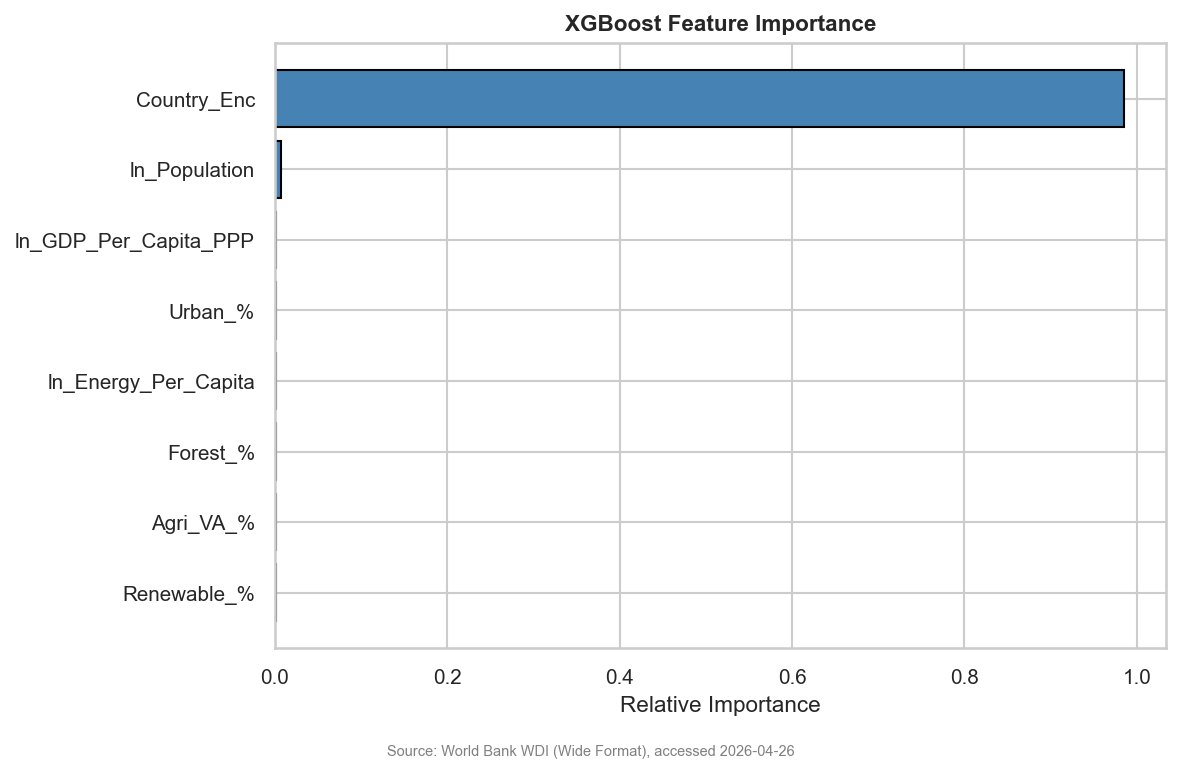

Saved: WS2_XGBoost_Importance.png

Country_Enc dominates (98.5%) — XGBoost is memorising country averages,
not learning structural relationships. FE is the better choice.


In [63]:
Importance = pd.DataFrame({
    'Feature': XGB_Features,
    'Importance': XGB_Model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(Importance.Feature, Importance.Importance, color='steelblue', edgecolor='black')
ax.set_title('XGBoost Feature Importance', fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_XGBoost_Importance.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_XGBoost_Importance.png')

# Flag if country encoding dominates
Top_Feat = Importance.iloc[-1]
if Top_Feat.Feature == 'Country_Enc':
    print(f'\nCountry_Enc dominates ({Top_Feat.Importance:.1%}) — XGBoost is memorising country averages,')
    print(f'not learning structural relationships. FE is the better choice.')

### Step 4(D) Actual vs Predicted

Each dot is one country in one validation year. 
* Points on the red diagonal = perfect prediction. 
* Tighter clustering around the line = better model.

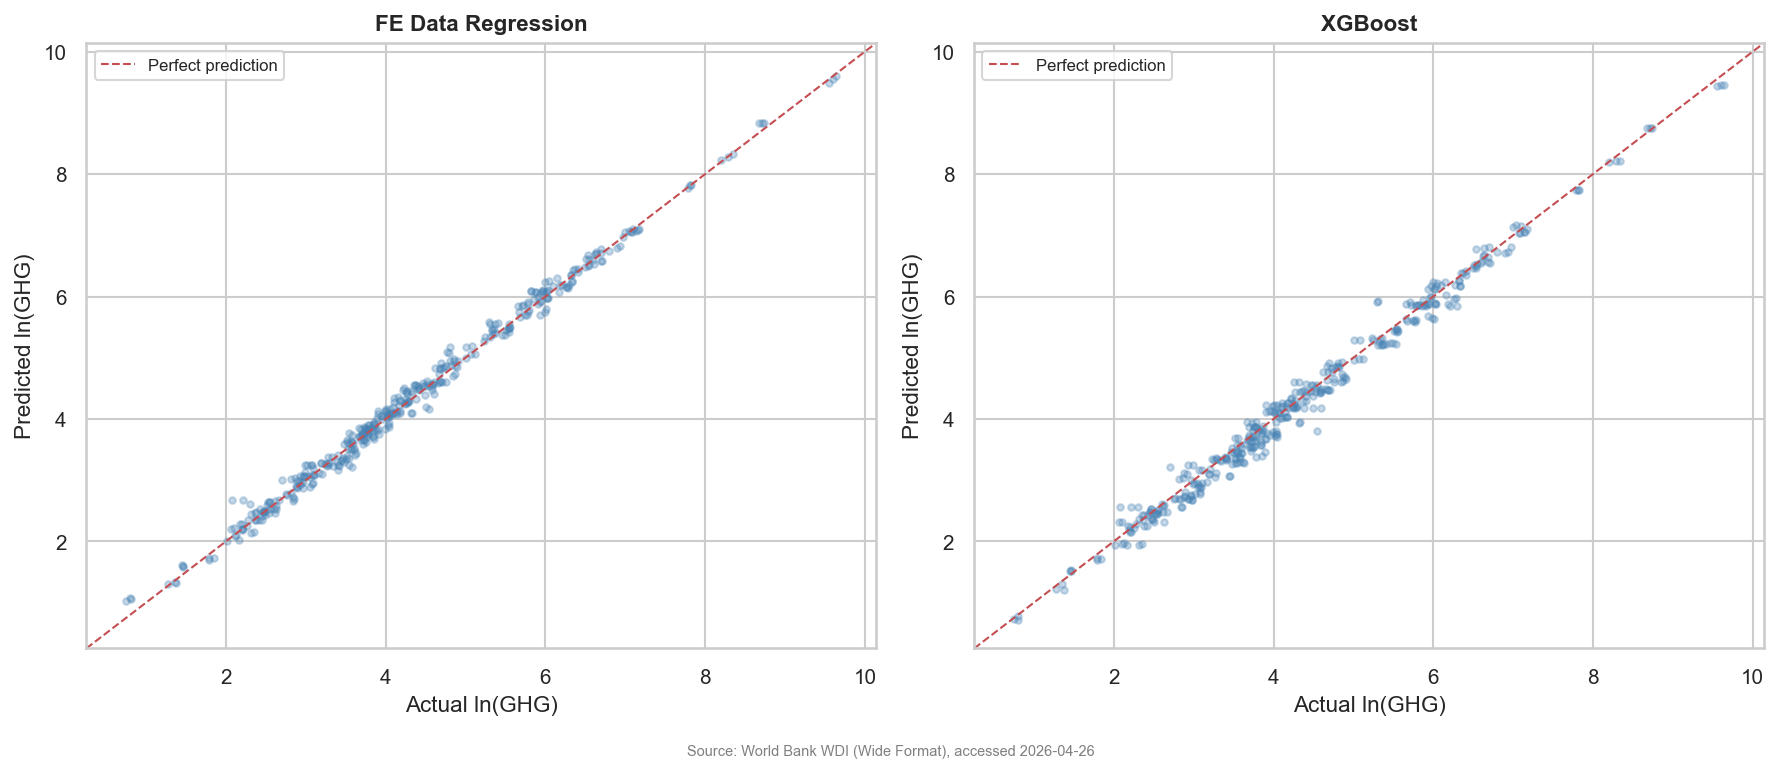

Saved: WS2_Actual_vs_Predicted.png


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lims = [Valid[Target].min() - 0.5, Valid[Target].max() + 0.5]

for ax, y_act, y_pred, title in [
    (axes[0], Valid[Target],   Valid['FE_Pred'],    'FE Data Regression'),
    (axes[1], Valid_X[Target], Valid_X['XGB_Pred'], 'XGBoost'),
]:
    ax.scatter(y_act, y_pred, alpha=0.3, s=10, color='steelblue')
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual ln(GHG)')
    ax.set_ylabel('Predicted ln(GHG)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_Actual_vs_Predicted.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_Actual_vs_Predicted.png')

## Step 5: Prediction for 2024

Predict 2024 GHG for all countries using both models, then focus on SE Asia.

Since 2024 actual data is available in WDI, we can compute prediction error. 
> The direction (over/under-prediction) tells us whether the model is conservative or aggressive for each region. 

* Step 5(A) **Predict 2024** 
<br> - Both models, for all countries.

* Step 5(B) **SE Asia focus** 
<br> - SE Asia focus table & bar chart

* Step 5(C) **95% Confidence Interval** 



### Step 5(A) 2024 Predictions

Run both FE and XGBoost on 2024 data. 
<br> Convert from log back to original scale (Mt CO₂e) for interpretability.

In [65]:
Pred['FE_Pred'] = FE_Predict(Pred, OLS.coef_, Country_Means_y, Country_Means_X, Pred_Cols)

Pred_X = Pred_X.copy()
Pred_X['XGB_Pred'] = XGB_Model.predict(Pred_X[XGB_Features].values)

# Combine into results table
Results = Pred[['Ref_Area', 'Year', Target, 'FE_Pred']].copy()
XGB_Map = dict(zip(Pred_X.Ref_Area, Pred_X['XGB_Pred']))
Results['XGB_Pred'] = Results['Ref_Area'].map(XGB_Map)

# Back to original scale (Mt CO₂e)
Results['GHG_Actual']   = np.exp(Results[Target])
Results['GHG_FE_Pred']  = np.exp(Results['FE_Pred'])
Results['GHG_XGB_Pred'] = np.exp(Results['XGB_Pred'])
Results['FE_Err_%']     = ((Results.GHG_FE_Pred - Results.GHG_Actual)
                            / Results.GHG_Actual * 100).round(1)
Results['XGB_Err_%']    = ((Results.GHG_XGB_Pred - Results.GHG_Actual)
                            / Results.GHG_Actual * 100).round(1)

### Step 5(B) SE Asia Focus

11 SE Asian countries with actual vs predicted values and error percentages.
* Negative error = model underpredicts (conservative). 
* Positive = model overpredicts (aggressive).

In [66]:
SEA = Results[Results.Ref_Area.isin(SE_Asia)]

print('=' * 72)
print('   2024 Predictions — SE Asia (Mt CO₂e)')
print('=' * 72)
print(SEA[['Ref_Area', 'GHG_Actual', 'GHG_FE_Pred', 'GHG_XGB_Pred',
           'FE_Err_%', 'XGB_Err_%']].round(2).to_string(index=False))
print('  ')

# Global metrics
print('=' * 72)
print(f'   2024 Global Accuracy')
print('=' * 72)
FE_2024 = Calc_Metrics(Results[Target].values, Results['FE_Pred'].values, 'FE — 2024')
print()
XGB_2024 = Calc_Metrics(Results[Target].values, Results['XGB_Pred'].values, 'XGBoost — 2024')

   2024 Predictions — SE Asia (Mt CO₂e)
Ref_Area  GHG_Actual  GHG_FE_Pred  GHG_XGB_Pred  FE_Err_%  XGB_Err_%
     BRN       11.87        11.45         10.40      -3.5      -12.4
     IDN     1323.78      1192.49       1190.10      -9.9      -10.1
     KHM       49.83        56.00         31.34      12.4      -37.1
     MMR      117.79       162.55        129.22      38.0        9.7
     MYS      332.17       303.29        271.63      -8.7      -18.2
     PHL      266.60       227.60        183.63     -14.6      -31.1
     SGP       76.09        73.19         64.98      -3.8      -14.6
     THA      422.39       395.14        359.24      -6.5      -15.0
     VNM      584.26       498.51        358.05     -14.7      -38.7
  
   2024 Global Accuracy
FE — 2024
  RMSE (log scale):  0.1561
  MAE  (log scale):  0.1239
  R²:                0.9903
  MAPE (orig scale): 13.0%

XGBoost — 2024
  RMSE (log scale):  0.2343
  MAE  (log scale):  0.1904
  R²:                0.9781
  MAPE (orig scale): 1

#### Visual comparison of actual vs FE vs XGBoost predictions for the SE Asian countries.

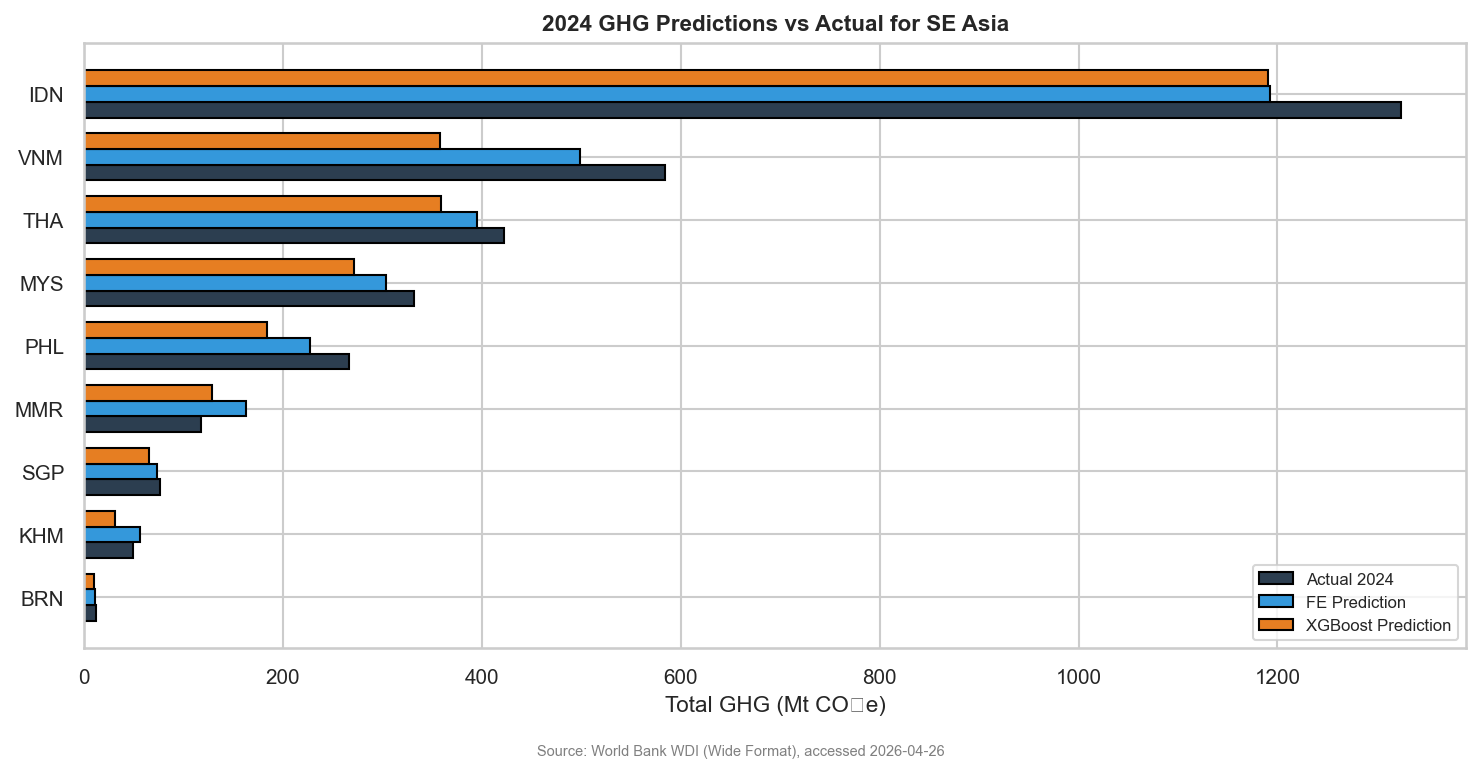

Saved: WS2_2024_Predictions_SEA.png


In [67]:
SEA_Plot = SEA.sort_values('GHG_Actual', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SEA_Plot))
w = 0.25

ax.barh(x - w, SEA_Plot.GHG_Actual,   w, label='Actual 2024',        color='#2c3e50', edgecolor='black')
ax.barh(x,     SEA_Plot.GHG_FE_Pred,  w, label='FE Prediction',      color='#3498db', edgecolor='black')
ax.barh(x + w, SEA_Plot.GHG_XGB_Pred, w, label='XGBoost Prediction', color='#e67e22', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(SEA_Plot.Ref_Area)
ax.set_xlabel('Total GHG (Mt CO₂e)')
ax.set_title('2024 GHG Predictions vs Actual for SE Asia', fontweight='bold')
ax.legend(fontsize=8)

plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_2024_Predictions_SEA.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_2024_Predictions_SEA.png')

### Step 5(C) SE Asia: 95% Confidence Interval &  Bar Chart

> CI = exp(ŷ ± 1.96 × SE_residual) 

where `SE_residual` is the standard deviation of validation residuals. 

If most 2024 actuals fall within this band, the model's uncertainty estimate is well-calibrated.

In [68]:
Residual_SE = Valid['FE_Resid'].dropna().std()

Results['CI_Lower'] = np.exp(Results['FE_Pred'] - 1.96 * Residual_SE)
Results['CI_Upper'] = np.exp(Results['FE_Pred'] + 1.96 * Residual_SE)

# SE Asia CI table
SEA_CI = Results[Results.Ref_Area.isin(SE_Asia)][
    ['Ref_Area', 'GHG_Actual', 'GHG_FE_Pred', 'CI_Lower', 'CI_Upper']]

print('=' * 72)
print('   2024 Predictions with 95% CI — SE Asia (Mt CO₂e)')
print('=' * 72)
print(SEA_CI.round(2).to_string(index=False))

# Global CI coverage
In_CI = ((Results.GHG_Actual >= Results.CI_Lower) &
         (Results.GHG_Actual <= Results.CI_Upper)).mean() * 100
print(f'\nCI coverage: {In_CI:.1f}% of 2024 actuals fall within the 95% CI')

   2024 Predictions with 95% CI — SE Asia (Mt CO₂e)
Ref_Area  GHG_Actual  GHG_FE_Pred  CI_Lower  CI_Upper
     BRN       11.87        11.45      8.97     14.62
     IDN     1323.78      1192.49    933.87   1522.73
     KHM       49.83        56.00     43.86     71.51
     MMR      117.79       162.55    127.30    207.56
     MYS      332.17       303.29    237.52    387.28
     PHL      266.60       227.60    178.24    290.63
     SGP       76.09        73.19     57.32     93.46
     THA      422.39       395.14    309.45    504.57
     VNM      584.26       498.51    390.40    636.56

CI coverage: 91.5% of 2024 actuals fall within the 95% CI


#### Visual comparison of actual vs FE vs XGBoost predictions for the all SE Asian countries.

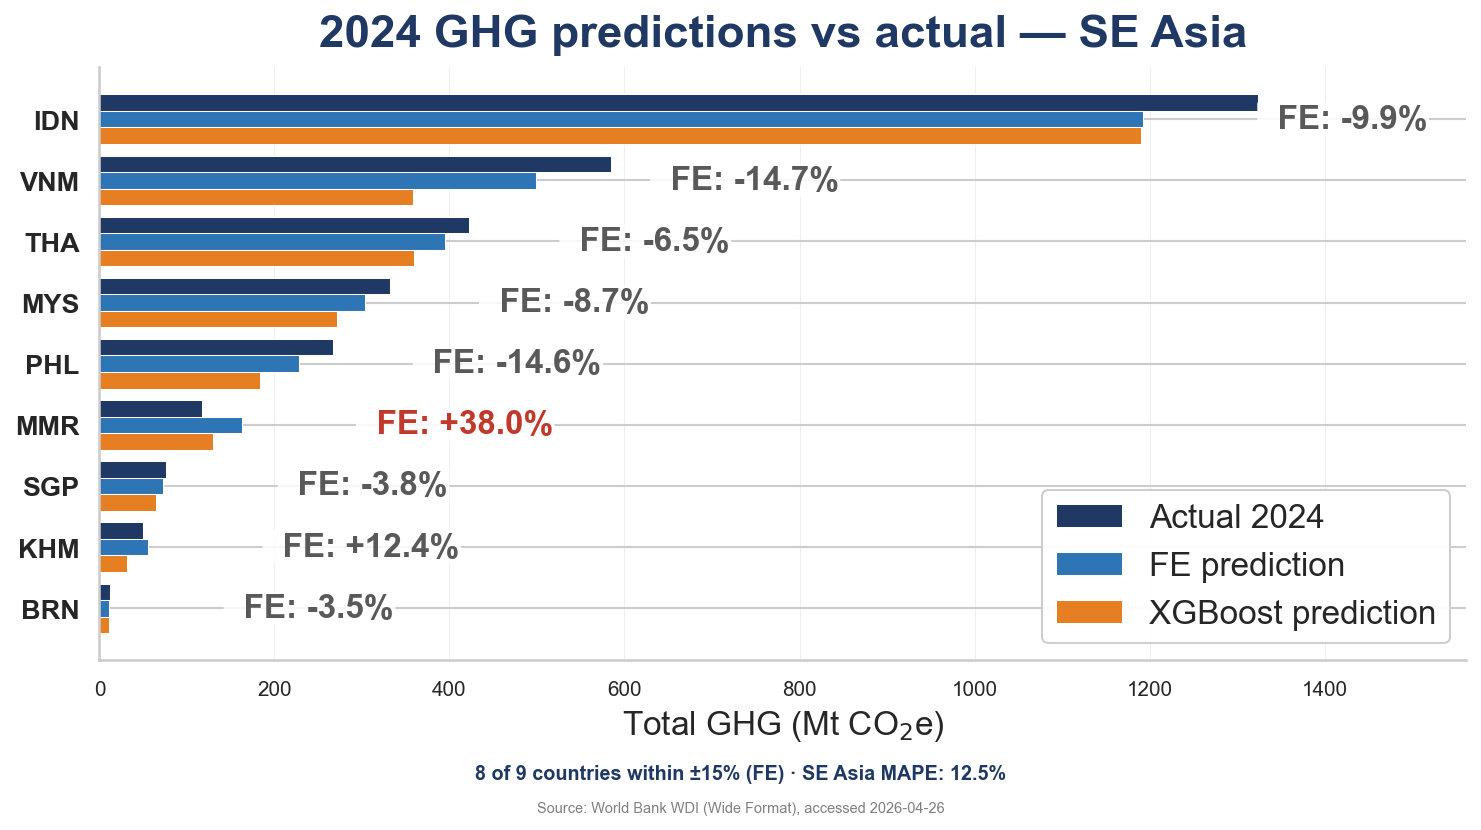

Saved: WS2_2024_Predictions_SEA.png


In [69]:
# Filter & sort SE Asia
SEA_Plot = (Results[Results.Ref_Area.isin(SE_Asia)]
            .sort_values('GHG_Actual', ascending=False)
            .reset_index(drop=True))

# Summary stats for the bottom takeaway line
N_Within_15 = (SEA_Plot['FE_Err_%'].abs() <= 15).sum()
N_Total     = len(SEA_Plot)
SEA_MAPE    = SEA_Plot['FE_Err_%'].abs().mean()
Summary     = f'{N_Within_15} of {N_Total} countries within \u00B115% (FE) \u00B7 SE Asia MAPE: {SEA_MAPE:.1f}%'

# Color palette (matches report)
NAVY, ACCENT, ORANGE, GREY = '#1F3864', '#2E75B6', '#E67E22', '#595959'

# Reverse so largest emitter (IDN) appears at the top
Sea_Rev = SEA_Plot.iloc[::-1].reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5.4))
x = np.arange(len(Sea_Rev))
w = 0.27

ax.barh(x + w, Sea_Rev.GHG_Actual,   w, label='Actual 2024',
        color=NAVY,   edgecolor='white', linewidth=0.5)
ax.barh(x,     Sea_Rev.GHG_FE_Pred,  w, label='FE prediction',
        color=ACCENT, edgecolor='white', linewidth=0.5)
ax.barh(x - w, Sea_Rev.GHG_XGB_Pred, w, label='XGBoost prediction',
        color=ORANGE, edgecolor='white', linewidth=0.5)

# FE error % labels at end of each FE bar
for i, row in Sea_Rev.iterrows():
    err    = row['FE_Err_%']
    sign   = '+' if err >= 0 else ''
    color  = '#C0392B' if abs(err) > 25 else GREY
    weight = 'bold'    if abs(err) > 25 else 'bold'
    ax.text(row.GHG_FE_Pred + Sea_Rev.GHG_Actual.max() * 0.1, i,
            f'  FE: {sign}{err:.1f}%',
            va='center', ha='left', fontsize=16,
            color=color, fontweight=weight, 
            bbox=dict(boxstyle='round,pad=0.05', facecolor='white',
                      edgecolor='none', alpha=0.85))

# Axis cosmetics
ax.set_yticks(x)
ax.set_yticklabels(Sea_Rev.Ref_Area, fontweight='bold', fontsize=13)
ax.set_xlabel('Total GHG (Mt CO$_2$e)', fontsize=16)
ax.set_title('2024 GHG predictions vs actual — SE Asia',
             fontweight='bold', fontsize=22, color=NAVY, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)
ax.legend(loc='lower right', fontsize=16, frameon=True, framealpha=0.95)
ax.set_xlim(0, max(Sea_Rev.GHG_Actual.max(), Sea_Rev.GHG_FE_Pred.max()) * 1.18)

# Bottom annotations
plt.figtext(0.5, 0.025, Summary,
            ha='center', fontsize=9.5, color=NAVY, fontweight='bold')
plt.figtext(0.5, -0.015, WDI_Source,
            ha='center', fontsize=7, color='grey')

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(Output_WS2 / 'WS2_2024_Predictions_SEA.png',
            bbox_inches='tight', dpi=200, facecolor='white')
plt.show()
print('Saved: WS2_2024_Predictions_SEA.png')

## Step 6: Export

Save outputs for WS4 (stress testing) and the dashboard.

| # | File | Used by | Purpose |
|---|------|---------|---------|
| 1 | `WS2_Coefficients.csv` | WS4 | Elasticities for mitigation scenario projections |
| 2 | `WS2_Validation_Metrics.csv` | Dashboard | Model comparison tab |
| 3 | `WS2_SEA_Predictions_2024.csv` | Dashboard | Country predictions tab |
| 4 | `WS2_XGB_Importance.csv` | Dashboard | Feature importance chart |
| 5 | `WS2_Country_Means_Y.csv` | WS4 | Country intercepts for prediction formula |
| 6 | `WS2_Country_Means_X.csv` | WS4 | Country predictor baselines for prediction formula |

In [70]:
# 1. Coefficients
coef_df.to_csv(Data_Path / 'WS2_Coefficients.csv', index=False)

# 2. Validation metrics
pd.DataFrame({
    'Model': ['FE Data Regression', 'XGBoost'],
    'RMSE':  [FE_Val_Metrics['RMSE'], XGB_Val_Metrics['RMSE']],
    'MAE':   [FE_Val_Metrics['MAE'],  XGB_Val_Metrics['MAE']],
    'R2':    [FE_Val_Metrics['R2'],   XGB_Val_Metrics['R2']],
    'MAPE':  [FE_Val_Metrics['MAPE'], XGB_Val_Metrics['MAPE']],
}).to_csv(Data_Path / 'WS2_Validation_Metrics.csv', index=False)

# 3. SE Asia 2024 predictions
Results[Results.Ref_Area.isin(SE_Asia)].to_csv(
    Data_Path / 'WS2_SEA_Predictions_2024.csv', index=False)

# 4. XGBoost feature importance
pd.DataFrame({
    'Feature': XGB_Features,
    'Importance': XGB_Model.feature_importances_
}).sort_values('Importance', ascending=False).to_csv(
    Data_Path / 'WS2_XGB_Importance.csv', index=False)

# 5. Country means (WS4 needs these for prediction formula)
Country_Means_y.to_csv(Data_Path / 'WS2_Country_Means_Y.csv')
Country_Means_X.to_csv(Data_Path / 'WS2_Country_Means_X.csv')

print('Exports saved to Data_Path/')
for f in ['WS2_Coefficients.csv', 'WS2_Validation_Metrics.csv',
          'WS2_SEA_Predictions_2024.csv', 'WS2_XGB_Importance.csv',
          'WS2_Country_Means_Y.csv', 'WS2_Country_Means_X.csv']:
    print(f'  {f}')

Exports saved to Data_Path/
  WS2_Coefficients.csv
  WS2_Validation_Metrics.csv
  WS2_SEA_Predictions_2024.csv
  WS2_XGB_Importance.csv
  WS2_Country_Means_Y.csv
  WS2_Country_Means_X.csv


## WS2 Complete, Handoff to WS4

**Model:** Fixed-effects data regression via manual demeaning + OLS.
<br> **Data:** 135 countries, trained 2000–2018, validated 2019/2022/2023, predicted 2024.
<br> **2020–2021:** Excluded entirely (pandemic distortion).

**For WS4 stress testing, use:**
1. Coefficient table from `WS2_Coefficients.csv`
2. Country means from `WS2_Country_Means_Y.csv` and `WS2_Country_Means_X.csv`
3. Prediction formula: ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train))
4. Shock the policy-actionable inputs (Renewable%, Energy/cap, Forest%) while holding GDP, Population, Urban% on BAU trajectories